In [1]:
import sys 
sys.path.append(r"C:\Users\hp\OneDrive - Bina Nusantara\NADZLA ANDRITA INTAN GHAYATRIE's files - ADASYN-Gaussian\hamra-work-adasyn\adasyn_gaussian")

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 


from adasyn_gaussian import AdasynGaussian

evaluate_k = AdasynGaussian.evaluate_k
adasyn_gaussian = AdasynGaussian.generate_synthetic_samples

# Dataset 6: Chronic Kidney Disease Prediction

source: https://www.kaggle.com/datasets/mansoordaku/ckdisease

In [3]:
df = pd.read_csv(r".\DATASET\kidney_disease.csv")
df

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [5]:
df.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [6]:
# Bersihkan data: strip whitespace dan tab pada kolom classification, dm, cad
df['classification'] = df['classification'].str.strip()
df['dm'] = df['dm'].str.strip()
df['cad'] = df['cad'].str.strip()

# Membuat target biner: ckd → 1 (minority), notckd → 0
# notckd sebagai minority class karena jumlahnya lebih sedikit
df['target'] = (df['classification'] == 'notckd').astype(int)
print("Distribusi kelas target:")
print(df['target'].value_counts())
print(f"\nRasio minority (notckd): {df['target'].mean():.4f}")

Distribusi kelas target:
target
0    250
1    150
Name: count, dtype: int64

Rasio minority (notckd): 0.3750


In [7]:
# Drop kolom identifier dan kolom classification (sudah dijadikan target)
df = df.drop(columns=['id', 'classification'])

# Konversi kolom pcv, wc, rc dari object ke numeric
df['pcv'] = pd.to_numeric(df['pcv'], errors='coerce')
df['wc'] = pd.to_numeric(df['wc'], errors='coerce')
df['rc'] = pd.to_numeric(df['rc'], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      353 non-null    float64
 3   al      354 non-null    float64
 4   su      351 non-null    float64
 5   rbc     248 non-null    object 
 6   pc      335 non-null    object 
 7   pcc     396 non-null    object 
 8   ba      396 non-null    object 
 9   bgr     356 non-null    float64
 10  bu      381 non-null    float64
 11  sc      383 non-null    float64
 12  sod     313 non-null    float64
 13  pot     312 non-null    float64
 14  hemo    348 non-null    float64
 15  pcv     329 non-null    float64
 16  wc      294 non-null    float64
 17  rc      269 non-null    float64
 18  htn     398 non-null    object 
 19  dm      398 non-null    object 
 20  cad     398 non-null    object 
 21  appet   399 non-null    object 
 22  pe

In [8]:
# Encode kolom kategorikal
binary_map = {
    'rbc': {'normal': 0, 'abnormal': 1},
    'pc': {'normal': 0, 'abnormal': 1},
    'pcc': {'notpresent': 0, 'present': 1},
    'ba': {'notpresent': 0, 'present': 1},
    'htn': {'no': 0, 'yes': 1},
    'dm': {'no': 0, 'yes': 1},
    'cad': {'no': 0, 'yes': 1},
    'appet': {'good': 0, 'poor': 1},
    'pe': {'no': 0, 'yes': 1},
    'ane': {'no': 0, 'yes': 1}
}

for col, mapping in binary_map.items():
    df[col] = df[col].map(mapping)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      353 non-null    float64
 3   al      354 non-null    float64
 4   su      351 non-null    float64
 5   rbc     248 non-null    float64
 6   pc      335 non-null    float64
 7   pcc     396 non-null    float64
 8   ba      396 non-null    float64
 9   bgr     356 non-null    float64
 10  bu      381 non-null    float64
 11  sc      383 non-null    float64
 12  sod     313 non-null    float64
 13  pot     312 non-null    float64
 14  hemo    348 non-null    float64
 15  pcv     329 non-null    float64
 16  wc      294 non-null    float64
 17  rc      269 non-null    float64
 18  htn     398 non-null    float64
 19  dm      398 non-null    float64
 20  cad     398 non-null    float64
 21  appet   399 non-null    float64
 22  pe

In [9]:
# Handle missing values: imputasi median untuk numerik
print("Missing values sebelum imputasi:")
print(df.isna().sum())
print(f"\nTotal missing: {df.isna().sum().sum()}")

# Imputasi dengan median per kolom
for col in df.columns:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("\nMissing values setelah imputasi:")
print(df.isna().sum().sum())

Missing values sebelum imputasi:
age         9
bp         12
sg         47
al         46
su         49
rbc       152
pc         65
pcc         4
ba          4
bgr        44
bu         19
sc         17
sod        87
pot        88
hemo       52
pcv        71
wc        106
rc        131
htn         2
dm          2
cad         2
appet       1
pe          1
ane         1
target      0
dtype: int64

Total missing: 1012

Missing values setelah imputasi:
0


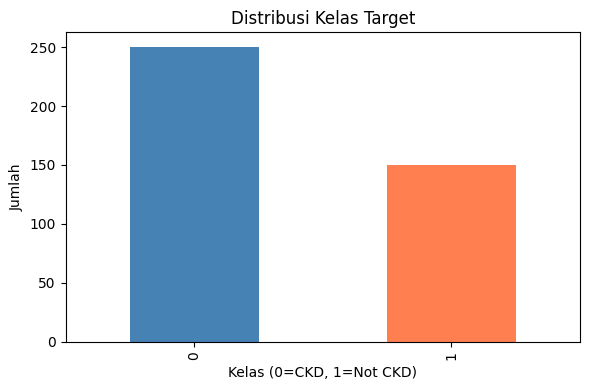

In [10]:
# Visualisasi distribusi kelas
fig, ax = plt.subplots(figsize=(6, 4))
df['target'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_title('Distribusi Kelas Target')
ax.set_xlabel('Kelas (0=CKD, 1=Not CKD)')
ax.set_ylabel('Jumlah')
plt.tight_layout()
plt.show()

In [11]:
# Korelasi fitur dengan target
corr_with_target = df.corr()['target'].drop('target').abs().sort_values(ascending=False)
print("Top 15 fitur berkorelasi dengan target:")
print(corr_with_target.head(15))

Top 15 fitur berkorelasi dengan target:
hemo     0.726368
pcv      0.673129
sg       0.659504
htn      0.590438
rc       0.566163
dm       0.559060
al       0.531562
appet    0.393341
bgr      0.379321
pc       0.375154
pe       0.375154
bu       0.369393
sod      0.334900
ane      0.325396
su       0.294555
Name: target, dtype: float64


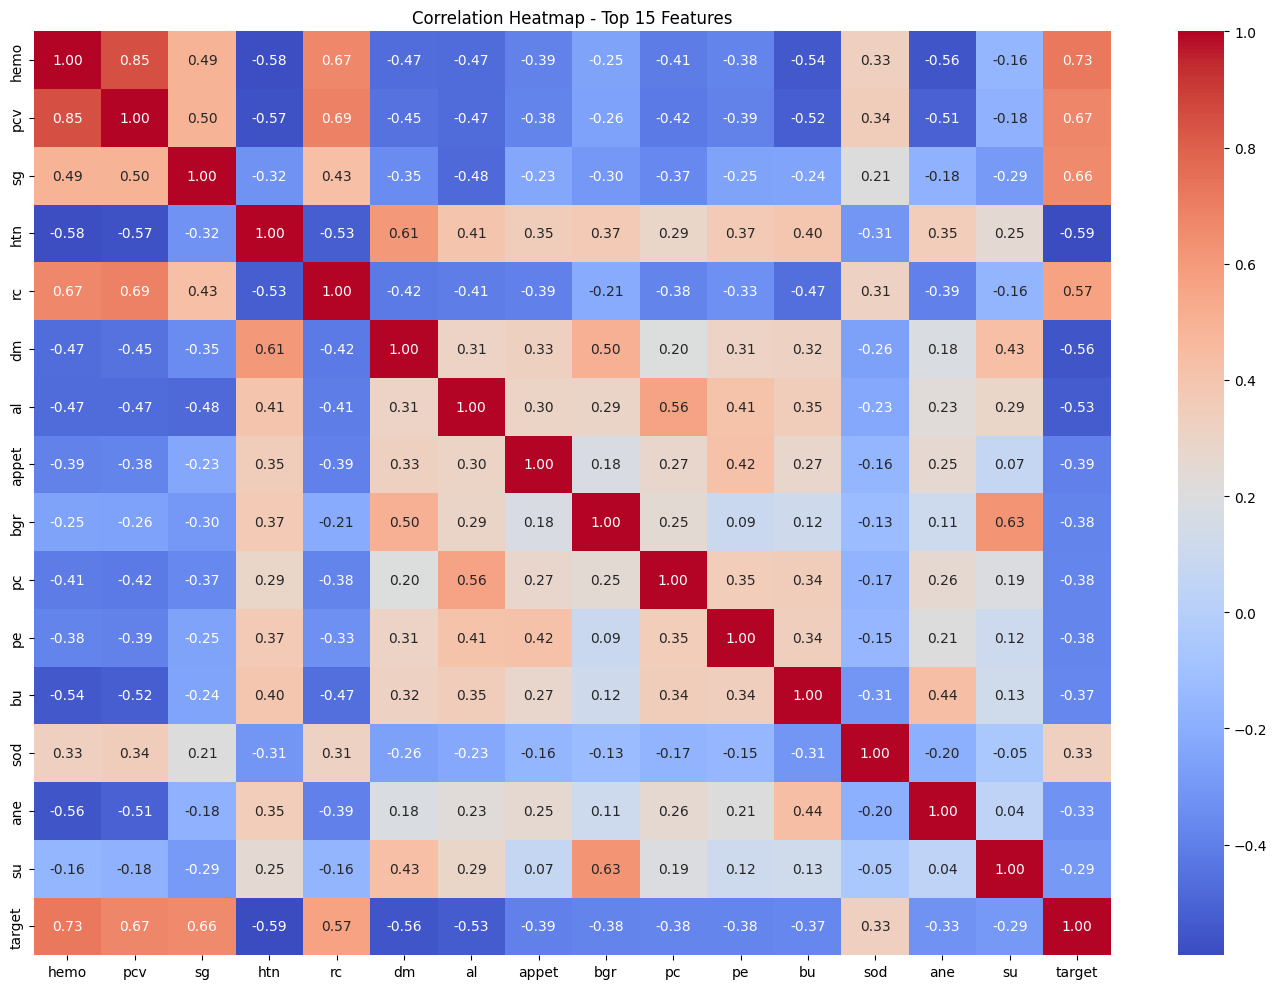

In [12]:
# Heatmap korelasi top 15 fitur + target
top_features = corr_with_target.head(15).index.tolist()
top_features.append('target')
plt.figure(figsize=(14, 10))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap - Top 15 Features')
plt.tight_layout()
plt.show()

Fitur kontinu untuk KDE plot: ['hemo', 'pcv', 'rc', 'bgr', 'bu', 'sod']


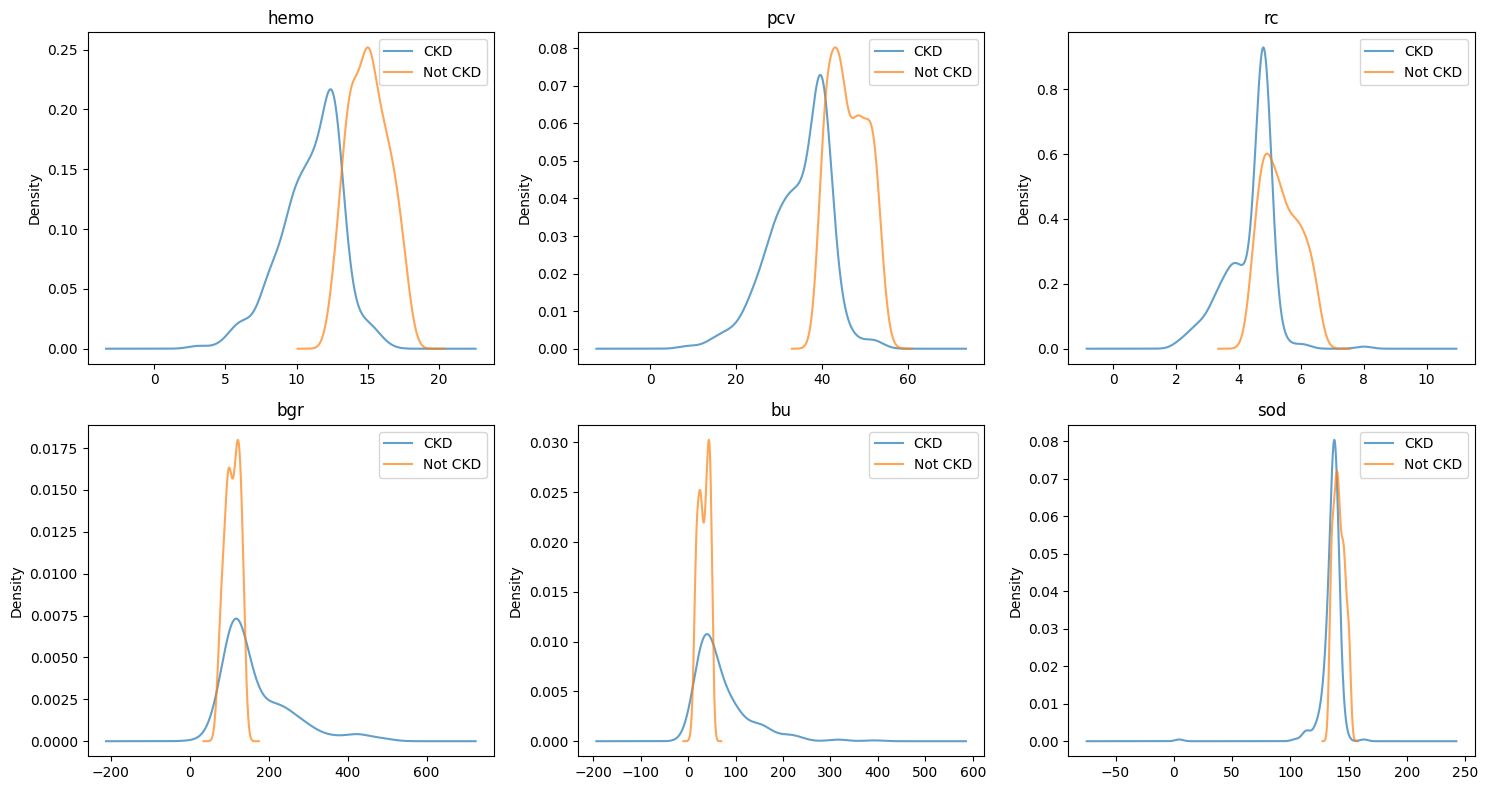

In [13]:
# Distribusi beberapa fitur kontinu terhadap target
# Filter hanya fitur dengan cukup variasi untuk KDE (>10 unique values per kelas)
binary_cols = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
kde_safe_cols = []
for col in corr_with_target.index:
    if col in binary_cols:
        continue
    n_unique_0 = df[df['target']==0][col].nunique()
    n_unique_1 = df[df['target']==1][col].nunique()
    if n_unique_0 > 10 and n_unique_1 > 10:
        kde_safe_cols.append(col)

top_6_cont = kde_safe_cols[:6]
print(f"Fitur kontinu untuk KDE plot: {top_6_cont}")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(top_6_cont):
    ax = axes.flatten()[i]
    df[df['target']==0][col].plot(kind='kde', ax=ax, label='CKD', alpha=0.7)
    df[df['target']==1][col].plot(kind='kde', ax=ax, label='Not CKD', alpha=0.7)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

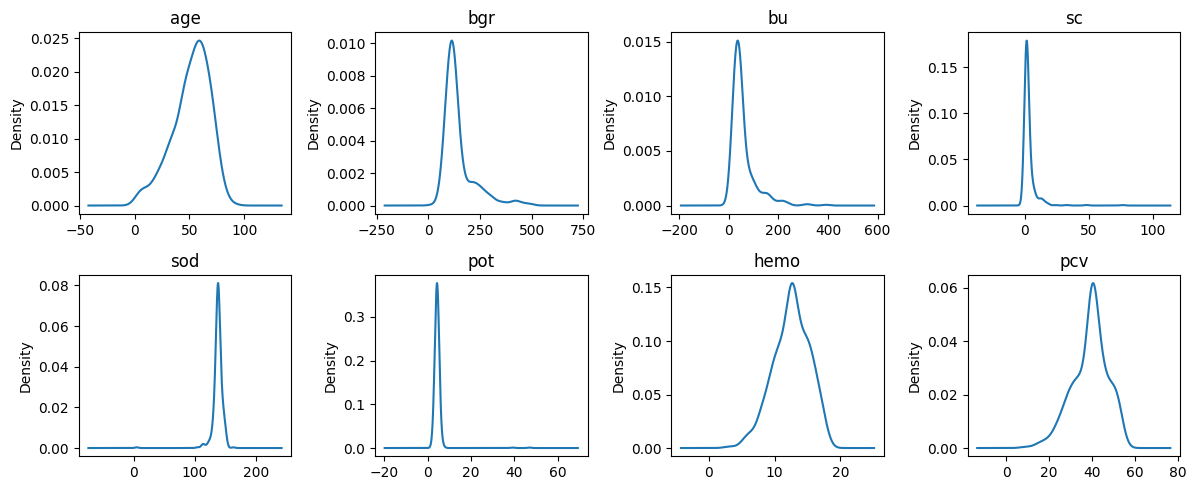

In [14]:
# Distribusi KDE beberapa fitur kontinu
continuous_features = [c for c in df.columns if c not in binary_cols + ['target']
                       and df[c].nunique() > 10]
sample_features = continuous_features[:8]
num_rows = 2
num_cols = 4

fig, ax = plt.subplots(num_rows, num_cols, figsize=(12, 5))

for i, column_name in enumerate(sample_features):
    df[column_name].plot(ax=ax.flatten()[i], kind='kde')
    ax.flatten()[i].set_title(column_name)

plt.tight_layout()
plt.show()

## Splitting Data

In [15]:
# DEFINE

minority_class = 1
X = df.loc[:, ~df.columns.isin(['target'])].values
y = df['target'].values

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Class distribution: {pd.Series(y).value_counts().to_dict()}")

X shape: (400, 24), y shape: (400,)
Class distribution: {0: 250, 1: 150}


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

# ADASYN-Gaussian + Decision Tree

In [17]:
# Define the range of k values to test
k_values = range(2, 10)
beta_values = [0.5, 1.0, 1.5, 2.0]

# d_threshold dinaikkan karena rasio minority/majority = 105/175 = 0.6 > default 0.5
# Sehingga ADASYN-Gaussian tetap menghasilkan sampel sintetis
D_THRESHOLD = 0.75

# Run the evaluation (menggunakan X_train, y_train untuk menghindari data leakage)
results = evaluate_k(X_train, y_train, k_values, beta_values, minority_class=minority_class, d_threshold=D_THRESHOLD)

# Find the optimal k
best_k, best_beta, best_f1 = max(results, key=lambda item: item[2])

print(f'Optimal k: {best_k}, Optimal Beta: {best_beta}, F1 score: {best_f1:.4f}')

results

Optimal k: 4, Optimal Beta: 0.5, F1 score: 0.8172


[(2, 0.5, 0.7852941176470588),
 (2, 1.0, 0.7923336547733848),
 (2, 1.5, 0.7671115323530918),
 (2, 2.0, 0.7598280098280098),
 (3, 0.5, 0.7961124896608768),
 (3, 1.0, 0.7852941176470588),
 (3, 1.5, 0.7745264130602186),
 (3, 2.0, 0.7561720498880716),
 (4, 0.5, 0.8171612903225807),
 (4, 1.0, 0.7819264069264069),
 (4, 1.5, 0.7707396301849075),
 (4, 2.0, 0.7745264130602186),
 (5, 0.5, 0.806689342403628),
 (5, 1.0, 0.7926135996171307),
 (5, 1.5, 0.7671115323530918),
 (5, 2.0, 0.7634744146150991),
 (6, 0.5, 0.803125),
 (6, 1.0, 0.7564139493797288),
 (6, 1.5, 0.7815724626520868),
 (6, 2.0, 0.7636854649598279),
 (7, 0.5, 0.8101902385778887),
 (7, 1.0, 0.7888683032268026),
 (7, 1.5, 0.7636854649598279),
 (7, 2.0, 0.7636854649598279),
 (8, 0.5, 0.7996553335670056),
 (8, 1.0, 0.788961038961039),
 (8, 1.5, 0.7564139493797288),
 (8, 2.0, 0.7781234349115844),
 (9, 0.5, 0.8066157014559627),
 (9, 1.0, 0.7671115323530918),
 (9, 1.5, 0.770921253479393),
 (9, 2.0, 0.7741687586454225)]

Proses Adasyn-Gaussian

In [18]:
# Menggunakan X_train, y_train untuk menghindari data leakage
X_synthetic, y_synthetic, synthetic_samples = adasyn_gaussian(X_train, y_train, k=best_k, beta=best_beta, minority_class=minority_class, d_threshold=D_THRESHOLD)
print(f"Menggunakan k={best_k}, beta={best_beta}, d_threshold={D_THRESHOLD}")

Menggunakan k=4, beta=0.5, d_threshold=0.75


In [19]:
print("Data Sintetis yang Dihasilkan:")
print(synthetic_samples)

Data Sintetis yang Dihasilkan:
[[ 1.18651794e+01  7.27274432e+01  1.01781725e+00  1.31935645e-03
  -4.76160882e-04 -1.52075826e-04  1.56737313e-03 -1.95975948e-04
  -1.52759286e-03  1.13403006e+02  2.55533516e+01  1.16454713e+00
   1.53903869e+02  4.64907557e+00  1.23080479e+01  4.63450176e+01
   8.49422162e+03  4.60517338e+00 -2.28392901e-04 -1.88553014e-03
  -7.73767961e-04  1.38757398e-03 -2.61003829e-03  6.97679415e-04]
 [ 6.17072208e+01  8.49015299e+01  1.02009817e+00 -1.41874528e-03
   1.84273295e-03  1.00999448e-04  9.75207092e-04 -1.58723659e-03
  -1.19566008e-03  1.23534892e+02  3.15749584e+01  1.18337265e+00
   1.43773006e+02  4.52071856e+00  1.44857961e+01  4.41325000e+01
   8.50473588e+03  5.01823915e+00  1.29941967e-03 -1.28186454e-03
   2.40764274e-04  3.02554937e-03  9.22444380e-04 -2.00652707e-03]
 [ 4.27267958e+01  7.14841705e+01  1.01717959e+00 -5.59036588e-04
   6.90281332e-04 -4.31901441e-04 -2.64038361e-03  8.22510068e-06
  -1.10773439e-05  1.25724458e+02  1.829884

In [20]:
print("Jumlah Sampel Sintetis yang Dihasilkan:", len(synthetic_samples))

Jumlah Sampel Sintetis yang Dihasilkan: 13


In [21]:
print("Jumlah Sampel di Kelas Minoritas Setelah Augmentasi:", sum(y_synthetic == minority_class))

Jumlah Sampel di Kelas Minoritas Setelah Augmentasi: 118


In [22]:
select_column = df.loc[:, ~df.columns.isin(['target'])]
df_x = pd.DataFrame(X_train, columns=select_column.columns)
df_x

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
0,55.0,70.0,1.010,0.0,2.0,0.0,0.0,0.0,0.0,220.0,...,8.7,27.0,8000.0,4.8,1.0,1.0,0.0,0.0,0.0,1.0
1,60.0,80.0,1.025,0.0,0.0,0.0,0.0,0.0,0.0,81.0,...,15.0,46.0,10500.0,5.3,0.0,0.0,0.0,0.0,0.0,0.0
2,20.0,70.0,1.020,0.0,0.0,0.0,0.0,0.0,0.0,123.0,...,14.6,44.0,5500.0,4.8,0.0,0.0,0.0,0.0,0.0,0.0
3,55.0,90.0,1.010,2.0,1.0,1.0,1.0,0.0,0.0,273.0,...,8.3,22.0,14600.0,2.9,1.0,1.0,0.0,1.0,1.0,1.0
4,34.0,70.0,1.020,0.0,0.0,0.0,0.0,0.0,0.0,121.0,...,6.0,40.0,8000.0,4.8,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,23.0,80.0,1.025,0.0,0.0,0.0,0.0,0.0,0.0,70.0,...,17.0,52.0,9800.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0
276,73.0,80.0,1.020,2.0,0.0,1.0,1.0,0.0,0.0,253.0,...,10.5,33.0,7200.0,4.3,1.0,1.0,1.0,0.0,0.0,0.0
277,60.0,60.0,1.010,3.0,1.0,0.0,1.0,1.0,0.0,288.0,...,7.9,25.0,15200.0,3.0,1.0,0.0,0.0,1.0,0.0,1.0
278,70.0,100.0,1.005,1.0,0.0,0.0,1.0,1.0,0.0,169.0,...,11.1,32.0,5800.0,5.0,1.0,1.0,0.0,1.0,0.0,0.0


In [23]:
synthetic_df = pd.DataFrame(synthetic_samples, columns=df_x.columns)
synthetic_df

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
0,11.865179,72.727443,1.017817,0.001319,-0.000476,-0.000152,0.001567,-0.000196,-0.001528,113.403006,...,12.308048,46.345018,8494.221619,4.605173,-0.000228,-0.001886,-0.000774,0.001388,-0.002610,0.000698
1,61.707221,84.901530,1.020098,-0.001419,0.001843,0.000101,0.000975,-0.001587,-0.001196,123.534892,...,14.485796,44.132500,8504.735882,5.018239,0.001299,-0.001282,0.000241,0.003026,0.000922,-0.002007
2,42.726796,71.484171,1.017180,-0.000559,0.000690,-0.000432,-0.002640,0.000008,-0.000011,125.724458,...,15.536736,46.442070,3521.960441,5.695506,0.000418,-0.001692,0.000443,-0.003229,0.000933,0.000950
3,66.137402,65.481581,1.020997,0.000025,0.002089,-0.001180,-0.001192,0.001668,0.000186,108.799534,...,14.454881,41.097198,10181.315207,4.829767,0.001703,0.000654,-0.000171,0.000964,-0.001663,-0.000631
4,34.802246,71.446088,1.022179,0.001293,0.000541,-0.000228,0.000335,0.000832,0.001228,105.254249,...,15.765389,45.196358,8912.295453,5.116591,0.000831,-0.000541,-0.000453,0.001782,-0.000348,-0.000738
5,63.060565,73.488326,1.023417,0.002585,0.000572,-0.001181,0.001782,0.004108,-0.000431,129.598188,...,13.894630,40.635341,7665.320789,5.300441,-0.001132,0.001302,-0.000028,-0.002097,-0.002209,0.000636
6,72.436193,73.934700,1.020856,-0.000552,-0.001074,0.000102,-0.000617,-0.000772,-0.001262,81.674669,...,16.945548,52.813262,6369.648914,5.715296,0.001797,0.001166,-0.000391,-0.000346,-0.000227,0.000885
7,50.723177,61.647375,1.020178,-0.001317,0.000996,0.000386,0.001344,-0.000371,0.001589,124.929622,...,14.128382,45.062572,8866.368576,4.632453,-0.000489,0.001323,0.001462,0.001703,-0.000647,0.001014
8,31.586532,65.756697,1.024567,0.002125,0.001716,0.001919,-0.001368,-0.002433,0.000631,105.959616,...,13.434417,43.931846,8215.054608,5.097629,-0.002630,-0.001444,-0.002160,0.000754,-0.001774,-0.001309
9,31.413940,86.291339,1.017169,-0.001599,-0.000637,-0.001349,0.000012,-0.000068,0.000165,77.497942,...,13.522975,48.654302,7488.129056,4.242649,0.000162,-0.001151,-0.000012,0.001995,-0.002022,-0.001747


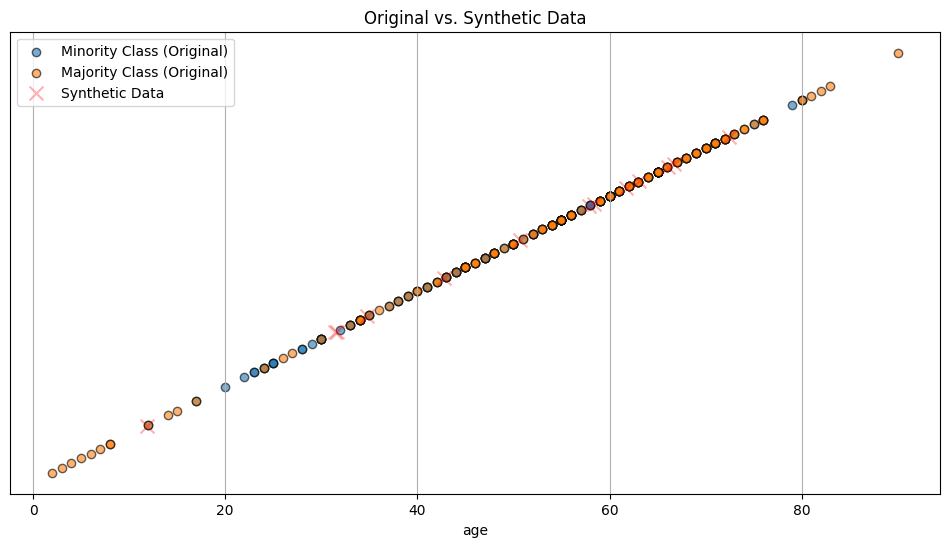

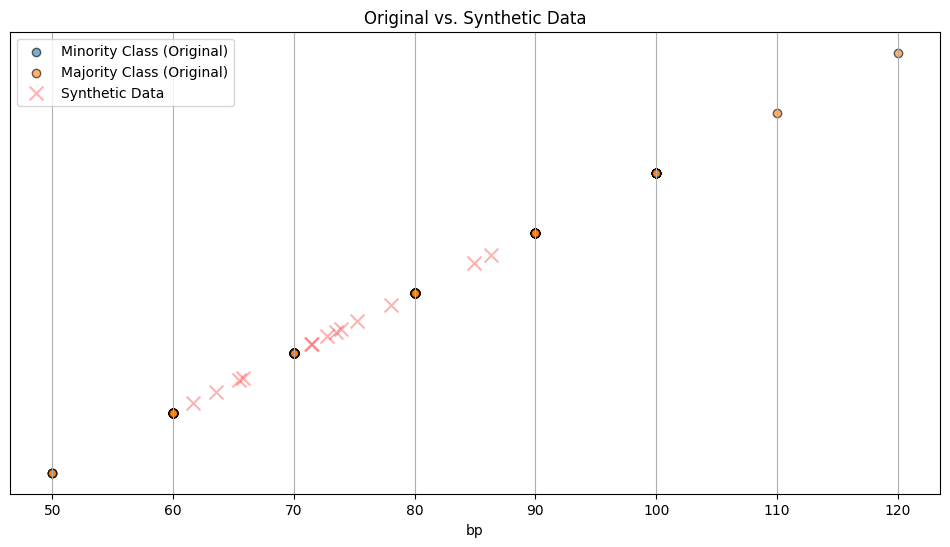

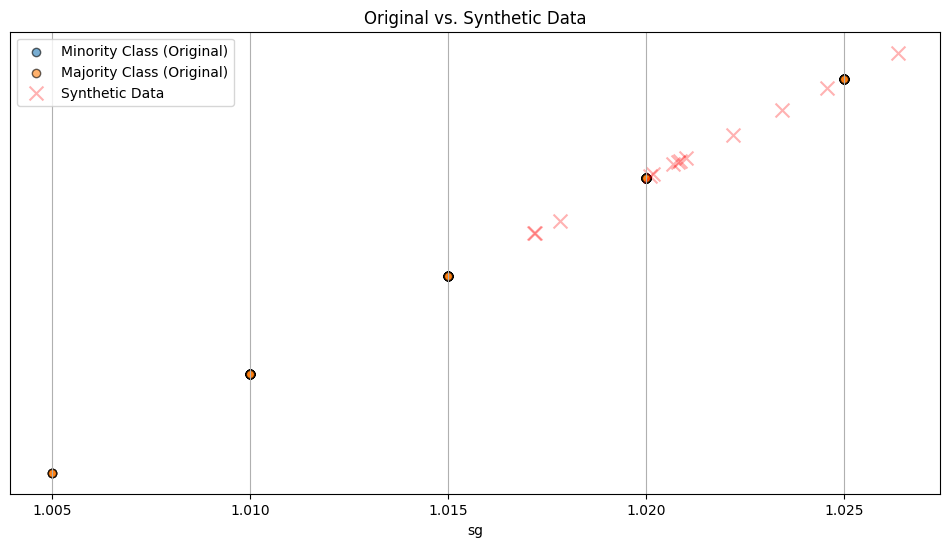

In [24]:
# Visualisasi Data Asli dan Sintetis
feature_names = select_column.columns.tolist()

def plot_synthetic_vs_original(X_train, y_train, synthetic_samples, feature_indices=0):
    plt.figure(figsize=(12, 6))
    
    # Plot data asli
    plt.scatter(X_train[y_train == 1, feature_indices], X_train[y_train == 1, feature_indices], label='Minority Class (Original)', alpha=0.6, edgecolor='k')
    plt.scatter(X_train[y_train == 0, feature_indices], X_train[y_train == 0, feature_indices], label='Majority Class (Original)', alpha=0.6, edgecolor='k')
    
    # Plot data sintetis
    plt.scatter(synthetic_samples[:, feature_indices], synthetic_samples[:, feature_indices], label='Synthetic Data', alpha=0.3, marker='x', color='r', s=100)
    
    plt.xlabel(feature_names[feature_indices])
    plt.yticks([])
    plt.title('Original vs. Synthetic Data')
    plt.legend()
    plt.grid(True)
    plt.show()

for feature_index in range(3):
    plot_synthetic_vs_original(X_train, y_train, synthetic_samples, feature_indices=feature_index)

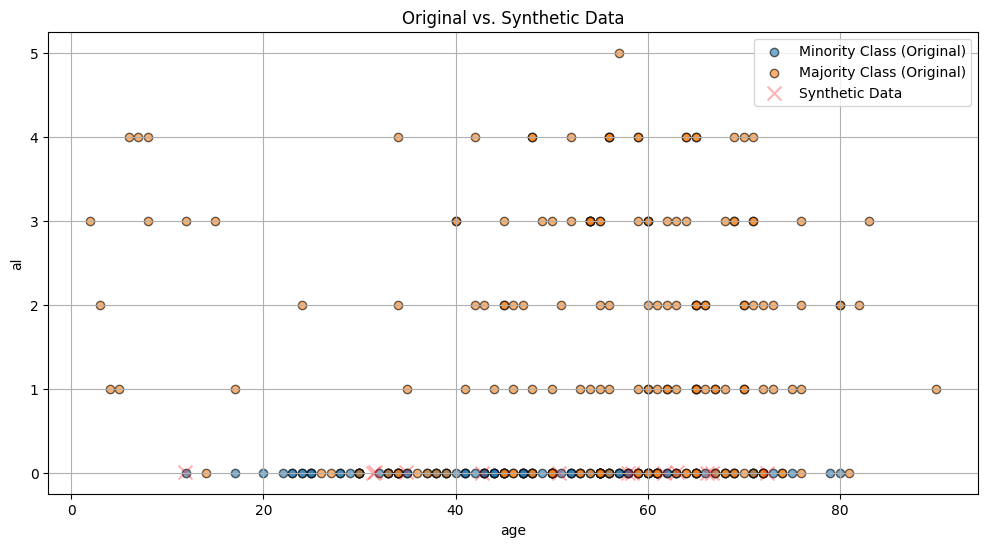

In [25]:
# Visualisasi Data Asli dan Sintetis (2D)
def plot_synthetic_vs_original_2d(X_train, y_train, synthetic_samples, feature_indices=[0, 1]):
    plt.figure(figsize=(12, 6))
    
    # Plot data asli
    plt.scatter(X_train[y_train == 1, feature_indices[0]], X_train[y_train== 1, feature_indices[1]], label='Minority Class (Original)', alpha=0.6, edgecolor='k')
    plt.scatter(X_train[y_train == 0, feature_indices[0]], X_train[y_train == 0, feature_indices[1]], label='Majority Class (Original)', alpha=0.6, edgecolor='k')
    
    # Plot data sintetis
    plt.scatter(synthetic_samples[:, feature_indices[0]], synthetic_samples[:, feature_indices[1]], label='Synthetic Data', alpha=0.3, s=100, marker='x', color='r')
    
    plt.xlabel(feature_names[feature_indices[0]])
    plt.ylabel(feature_names[feature_indices[1]])
    plt.title('Original vs. Synthetic Data')
    plt.legend()
    plt.grid(True)
    plt.show()

feature_indices = [0, 3]
plot_synthetic_vs_original_2d(X_train, y_train, synthetic_samples, feature_indices)

In [26]:
display(df_x.head(5), synthetic_df.head(5))

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
0,55.0,70.0,1.010,0.0,2.0,0.0,0.0,0.0,0.0,220.0,...,8.7,27.0,8000.0,4.8,1.0,1.0,0.0,0.0,0.0,1.0
1,60.0,80.0,1.025,0.0,0.0,0.0,0.0,0.0,0.0,81.0,...,15.0,46.0,10500.0,5.3,0.0,0.0,0.0,0.0,0.0,0.0
2,20.0,70.0,1.020,0.0,0.0,0.0,0.0,0.0,0.0,123.0,...,14.6,44.0,5500.0,4.8,0.0,0.0,0.0,0.0,0.0,0.0
3,55.0,90.0,1.010,2.0,1.0,1.0,1.0,0.0,0.0,273.0,...,8.3,22.0,14600.0,2.9,1.0,1.0,0.0,1.0,1.0,1.0
4,34.0,70.0,1.020,0.0,0.0,0.0,0.0,0.0,0.0,121.0,...,6.0,40.0,8000.0,4.8,1.0,0.0,0.0,0.0,0.0,1.0


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
0,11.865179,72.727443,1.017817,0.001319,-0.000476,-0.000152,0.001567,-0.000196,-0.001528,113.403006,...,12.308048,46.345018,8494.221619,4.605173,-0.000228,-0.001886,-0.000774,0.001388,-0.002610,0.000698
1,61.707221,84.901530,1.020098,-0.001419,0.001843,0.000101,0.000975,-0.001587,-0.001196,123.534892,...,14.485796,44.132500,8504.735882,5.018239,0.001299,-0.001282,0.000241,0.003026,0.000922,-0.002007
2,42.726796,71.484171,1.017180,-0.000559,0.000690,-0.000432,-0.002640,0.000008,-0.000011,125.724458,...,15.536736,46.442070,3521.960441,5.695506,0.000418,-0.001692,0.000443,-0.003229,0.000933,0.000950
3,66.137402,65.481581,1.020997,0.000025,0.002089,-0.001180,-0.001192,0.001668,0.000186,108.799534,...,14.454881,41.097198,10181.315207,4.829767,0.001703,0.000654,-0.000171,0.000964,-0.001663,-0.000631
4,34.802246,71.446088,1.022179,0.001293,0.000541,-0.000228,0.000335,0.000832,0.001228,105.254249,...,15.765389,45.196358,8912.295453,5.116591,0.000831,-0.000541,-0.000453,0.001782,-0.000348,-0.000738


In [27]:
synthetic_df['target'] = "Synthetic"
synthetic_df

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,target
0,11.865179,72.727443,1.017817,0.001319,-0.000476,-0.000152,0.001567,-0.000196,-0.001528,113.403006,...,46.345018,8494.221619,4.605173,-0.000228,-0.001886,-0.000774,0.001388,-0.002610,0.000698,Synthetic
1,61.707221,84.901530,1.020098,-0.001419,0.001843,0.000101,0.000975,-0.001587,-0.001196,123.534892,...,44.132500,8504.735882,5.018239,0.001299,-0.001282,0.000241,0.003026,0.000922,-0.002007,Synthetic
2,42.726796,71.484171,1.017180,-0.000559,0.000690,-0.000432,-0.002640,0.000008,-0.000011,125.724458,...,46.442070,3521.960441,5.695506,0.000418,-0.001692,0.000443,-0.003229,0.000933,0.000950,Synthetic
3,66.137402,65.481581,1.020997,0.000025,0.002089,-0.001180,-0.001192,0.001668,0.000186,108.799534,...,41.097198,10181.315207,4.829767,0.001703,0.000654,-0.000171,0.000964,-0.001663,-0.000631,Synthetic
4,34.802246,71.446088,1.022179,0.001293,0.000541,-0.000228,0.000335,0.000832,0.001228,105.254249,...,45.196358,8912.295453,5.116591,0.000831,-0.000541,-0.000453,0.001782,-0.000348,-0.000738,Synthetic
5,63.060565,73.488326,1.023417,0.002585,0.000572,-0.001181,0.001782,0.004108,-0.000431,129.598188,...,40.635341,7665.320789,5.300441,-0.001132,0.001302,-0.000028,-0.002097,-0.002209,0.000636,Synthetic
6,72.436193,73.934700,1.020856,-0.000552,-0.001074,0.000102,-0.000617,-0.000772,-0.001262,81.674669,...,52.813262,6369.648914,5.715296,0.001797,0.001166,-0.000391,-0.000346,-0.000227,0.000885,Synthetic
7,50.723177,61.647375,1.020178,-0.001317,0.000996,0.000386,0.001344,-0.000371,0.001589,124.929622,...,45.062572,8866.368576,4.632453,-0.000489,0.001323,0.001462,0.001703,-0.000647,0.001014,Synthetic
8,31.586532,65.756697,1.024567,0.002125,0.001716,0.001919,-0.001368,-0.002433,0.000631,105.959616,...,43.931846,8215.054608,5.097629,-0.002630,-0.001444,-0.002160,0.000754,-0.001774,-0.001309,Synthetic
9,31.413940,86.291339,1.017169,-0.001599,-0.000637,-0.001349,0.000012,-0.000068,0.000165,77.497942,...,48.654302,7488.129056,4.242649,0.000162,-0.001151,-0.000012,0.001995,-0.002022,-0.001747,Synthetic


In [28]:
# Data sintetis sudah siap (semua fitur numerik, tidak perlu konversi tipe)
synthetic_df.dtypes

age       float64
bp        float64
sg        float64
al        float64
su        float64
rbc       float64
pc        float64
pcc       float64
ba        float64
bgr       float64
bu        float64
sc        float64
sod       float64
pot       float64
hemo      float64
pcv       float64
wc        float64
rc        float64
htn       float64
dm        float64
cad       float64
appet     float64
pe        float64
ane       float64
target     object
dtype: object

In [29]:
# Menggunakan data augmentasi langsung dari X_synthetic, y_synthetic
X_train_ag = X_synthetic
y_train_ag = y_synthetic

print(f"Training set size: {len(X_train_ag)}")
print(f"Test set size: {len(X_test)}")
print(f"Training class distribution: {pd.Series(y_train_ag).value_counts().to_dict()}")

Training set size: 293
Test set size: 120
Training class distribution: {0: 175, 1: 118}


In [30]:
# Distribusi kelas setelah augmentasi
print("Distribusi kelas training setelah ADASYN-Gaussian:")
print(pd.Series(y_train_ag).value_counts())

Distribusi kelas training setelah ADASYN-Gaussian:
0    175
1    118
Name: count, dtype: int64


In [31]:
# Info training data
print(f"X_train_ag shape: {X_train_ag.shape}")
print(f"y_train_ag shape: {y_train_ag.shape}")
print(f"X_test shape: {X_test.shape}")

X_train_ag shape: (293, 24)
y_train_ag shape: (293,)
X_test shape: (120, 24)


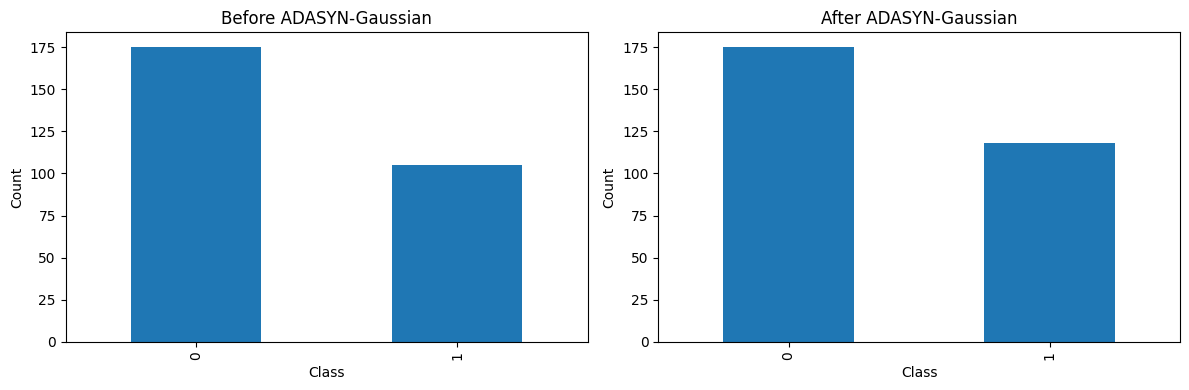

In [32]:
# Visualisasi distribusi kelas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0], title='Before ADASYN-Gaussian')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
pd.Series(y_train_ag).value_counts().plot(kind='bar', ax=axes[1], title='After ADASYN-Gaussian')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

In [33]:
# Test set tetap menggunakan X_test, y_test dari train_test_split
X_test_ag = X_test
y_test_ag = y_test
print(f"X_test_ag shape: {X_test_ag.shape}")

X_test_ag shape: (120, 24)


## Normalization

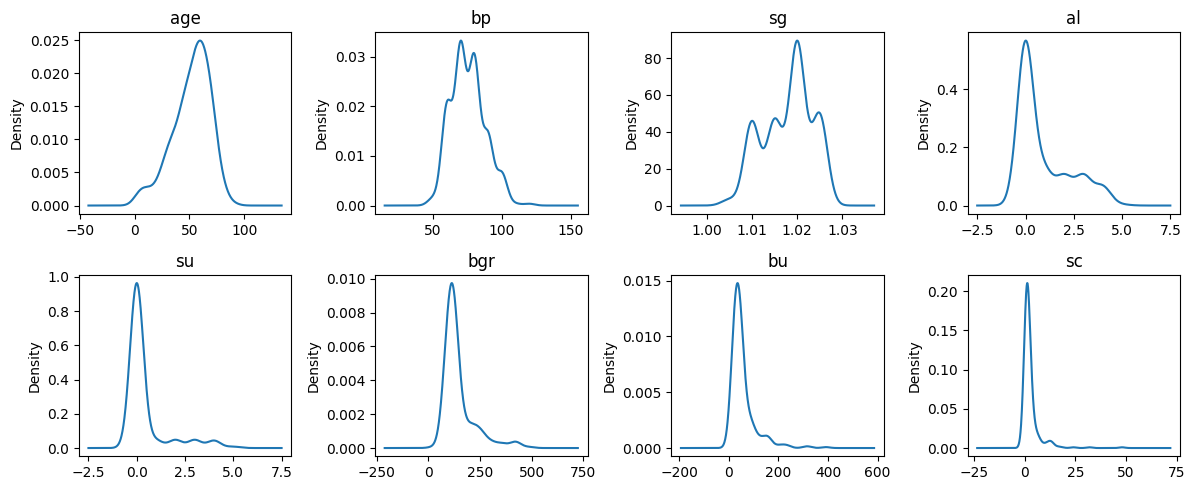

In [34]:
# Visualisasi distribusi fitur sebelum normalisasi (8 fitur kontinu pertama)
select_column = df.loc[:, ~df.columns.isin(['target'])]
df_train_viz = pd.DataFrame(X_train_ag, columns=select_column.columns)

continuous_features = [c for c in df_train_viz.columns if c not in binary_cols
                       and df_train_viz[c].nunique() > 10]
sample_cols = continuous_features[:8]
num_rows = 2
num_cols = 4

fig, ax = plt.subplots(num_rows, num_cols, figsize=(12, 5))

for i, column_name in enumerate(sample_cols):
    df_train_viz[column_name].plot(ax=ax.flatten()[i], kind='kde')
    ax.flatten()[i].set_title(column_name)

plt.tight_layout()
plt.show()

In [35]:
# Pastikan y_train_ag adalah integer
y_train_ag = np.array(y_train_ag).astype(int)
y_test_ag = np.array(y_test_ag).astype(int)
print(f"y_train_ag dtype: {y_train_ag.dtype}, y_test_ag dtype: {y_test_ag.dtype}")

y_train_ag dtype: int64, y_test_ag dtype: int64


In [36]:
from sklearn.preprocessing import QuantileTransformer

n_samples = X_train_ag.shape[0]
transformer = QuantileTransformer(n_quantiles=min(n_samples, 1000), output_distribution='normal')

X_train_ag_scaled = transformer.fit_transform(X_train_ag)
X_test_ag_scaled = transformer.transform(X_test_ag)

print(f"X_train_ag_scaled shape: {X_train_ag_scaled.shape}")
print(f"X_test_ag_scaled shape: {X_test_ag_scaled.shape}")

X_train_ag_scaled shape: (293, 24)
X_test_ag_scaled shape: (120, 24)


## Classification

In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, classification_report, precision_score, 
                             recall_score, f1_score, roc_auc_score, roc_curve, 
                             confusion_matrix, ConfusionMatrixDisplay)

In [38]:
dt = DecisionTreeClassifier(random_state=42)

In [39]:
param_grid = {
    'max_depth': [10, 20, 30],        
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 2, 4]   
}

# Initialize GridSearchCV
grid_search = GridSearchCV(dt, param_grid, cv=10, scoring='accuracy', verbose=2, n_jobs=-1)

# Fit the model
grid_search.fit(X_train_ag_scaled, y_train_ag)

Fitting 10 folds for each of 27 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

In [40]:
# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Best Parameters: {best_params}")
print(f"Best Score: {best_score}")

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best Score: 0.9624137931034482


In [41]:
y_pred = grid_search.best_estimator_.predict(X_test_ag_scaled)

In [42]:
print("=== ADASYN-Gaussian + Decision Tree (Chronic Kidney Disease) ===")
print("Akurasi      :", accuracy_score(y_test_ag, y_pred))
print("Precision    :", precision_score(y_test_ag, y_pred))
print("Recall       :", recall_score(y_test_ag, y_pred))
print("F1 Score     :", f1_score(y_test_ag, y_pred))

=== ADASYN-Gaussian + Decision Tree (Chronic Kidney Disease) ===
Akurasi      : 0.95
Precision    : 0.9148936170212766
Recall       : 0.9555555555555556
F1 Score     : 0.9347826086956522


              precision    recall  f1-score   support

           0       0.97      0.95      0.96        75
           1       0.91      0.96      0.93        45

    accuracy                           0.95       120
   macro avg       0.94      0.95      0.95       120
weighted avg       0.95      0.95      0.95       120



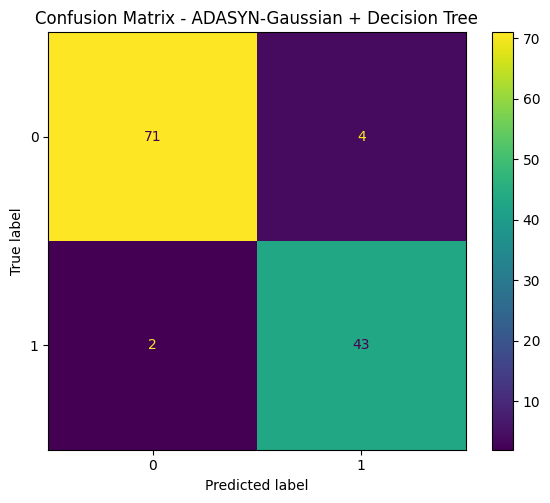

In [43]:
# Classification report
report = classification_report(y_test_ag, y_pred, zero_division=1)
print(report)

# Confusion Matrix
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_ag, y_pred, ax=ax)
ax.set_title('Confusion Matrix - ADASYN-Gaussian + Decision Tree')
plt.tight_layout()
plt.show()

# ADASYN + Decision Tree

## ROC-AUC Curve - ADASYN-Gaussian + Decision Tree

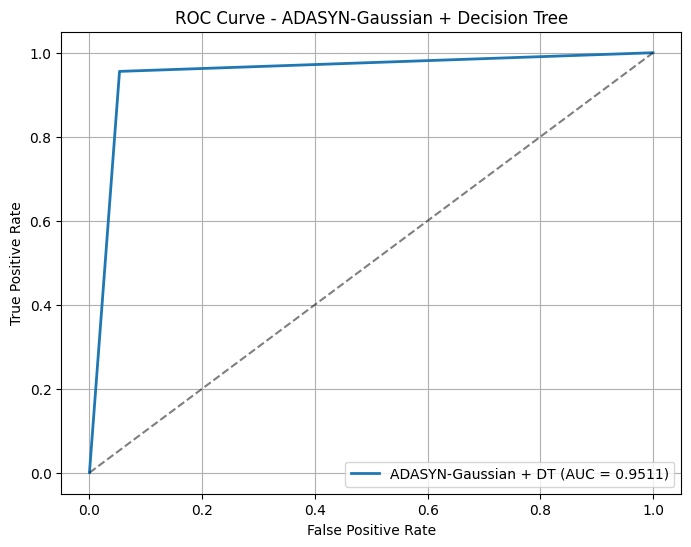

ROC-AUC Score: 0.9511


In [44]:
# ROC-AUC Curve untuk ADASYN-Gaussian + Decision Tree
y_prob_ag = grid_search.best_estimator_.predict_proba(X_test_ag_scaled)[:, 1]
fpr_ag, tpr_ag, _ = roc_curve(y_test_ag, y_prob_ag)
auc_ag = roc_auc_score(y_test_ag, y_prob_ag)

plt.figure(figsize=(8, 6))
plt.plot(fpr_ag, tpr_ag, label=f'ADASYN-Gaussian + DT (AUC = {auc_ag:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ADASYN-Gaussian + Decision Tree')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"ROC-AUC Score: {auc_ag:.4f}")

## Perbandingan Multiple Classifiers - ADASYN-Gaussian

In [45]:
# Perbandingan Multiple Classifiers dengan ADASYN-Gaussian
classifiers = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'DT (class_weight=balanced)': DecisionTreeClassifier(class_weight='balanced', random_state=42)
}

results_ag = []
roc_data_ag = {}

for name, clf in classifiers.items():
    print(f"Training {name}...")
    clf.fit(X_train_ag_scaled, y_train_ag)
    y_pred_clf = clf.predict(X_test_ag_scaled)
    y_prob_clf = clf.predict_proba(X_test_ag_scaled)[:, 1]
    
    acc = accuracy_score(y_test_ag, y_pred_clf)
    prec = precision_score(y_test_ag, y_pred_clf, zero_division=0)
    rec = recall_score(y_test_ag, y_pred_clf, zero_division=0)
    f1 = f1_score(y_test_ag, y_pred_clf, zero_division=0)
    auc = roc_auc_score(y_test_ag, y_prob_clf)
    
    results_ag.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    })
    
    fpr_clf, tpr_clf, _ = roc_curve(y_test_ag, y_prob_clf)
    roc_data_ag[name] = (fpr_clf, tpr_clf, auc)

results_ag_df = pd.DataFrame(results_ag).sort_values('F1 Score', ascending=False)
print("\n=== Hasil Perbandingan Classifiers dengan ADASYN-Gaussian ===")
display(results_ag_df)

Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training SVM...
Training Logistic Regression...
Training DT (class_weight=balanced)...

=== Hasil Perbandingan Classifiers dengan ADASYN-Gaussian ===


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
2,Gradient Boosting,0.9917,0.9783,1.0000,0.9890,1.0000
4,Logistic Regression,0.9833,0.9574,1.0000,0.9783,0.9997
0,Decision Tree,0.9750,0.9773,0.9556,0.9663,0.9711
5,DT (class_weight=balanced),0.9750,0.9773,0.9556,0.9663,0.9711
3,SVM,0.9583,0.9000,1.0000,0.9474,0.9997


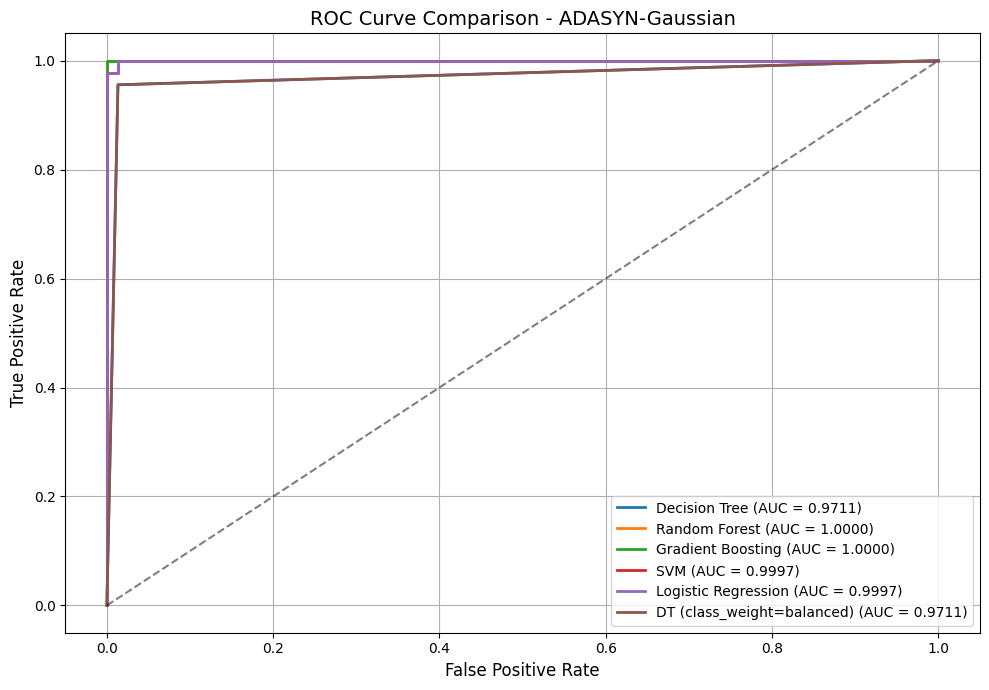

In [46]:
# ROC Curve Comparison - Semua Classifiers (ADASYN-Gaussian)
plt.figure(figsize=(10, 7))
for name, (fpr_clf, tpr_clf, auc_clf) in roc_data_ag.items():
    plt.plot(fpr_clf, tpr_clf, label=f'{name} (AUC = {auc_clf:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison - ADASYN-Gaussian', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

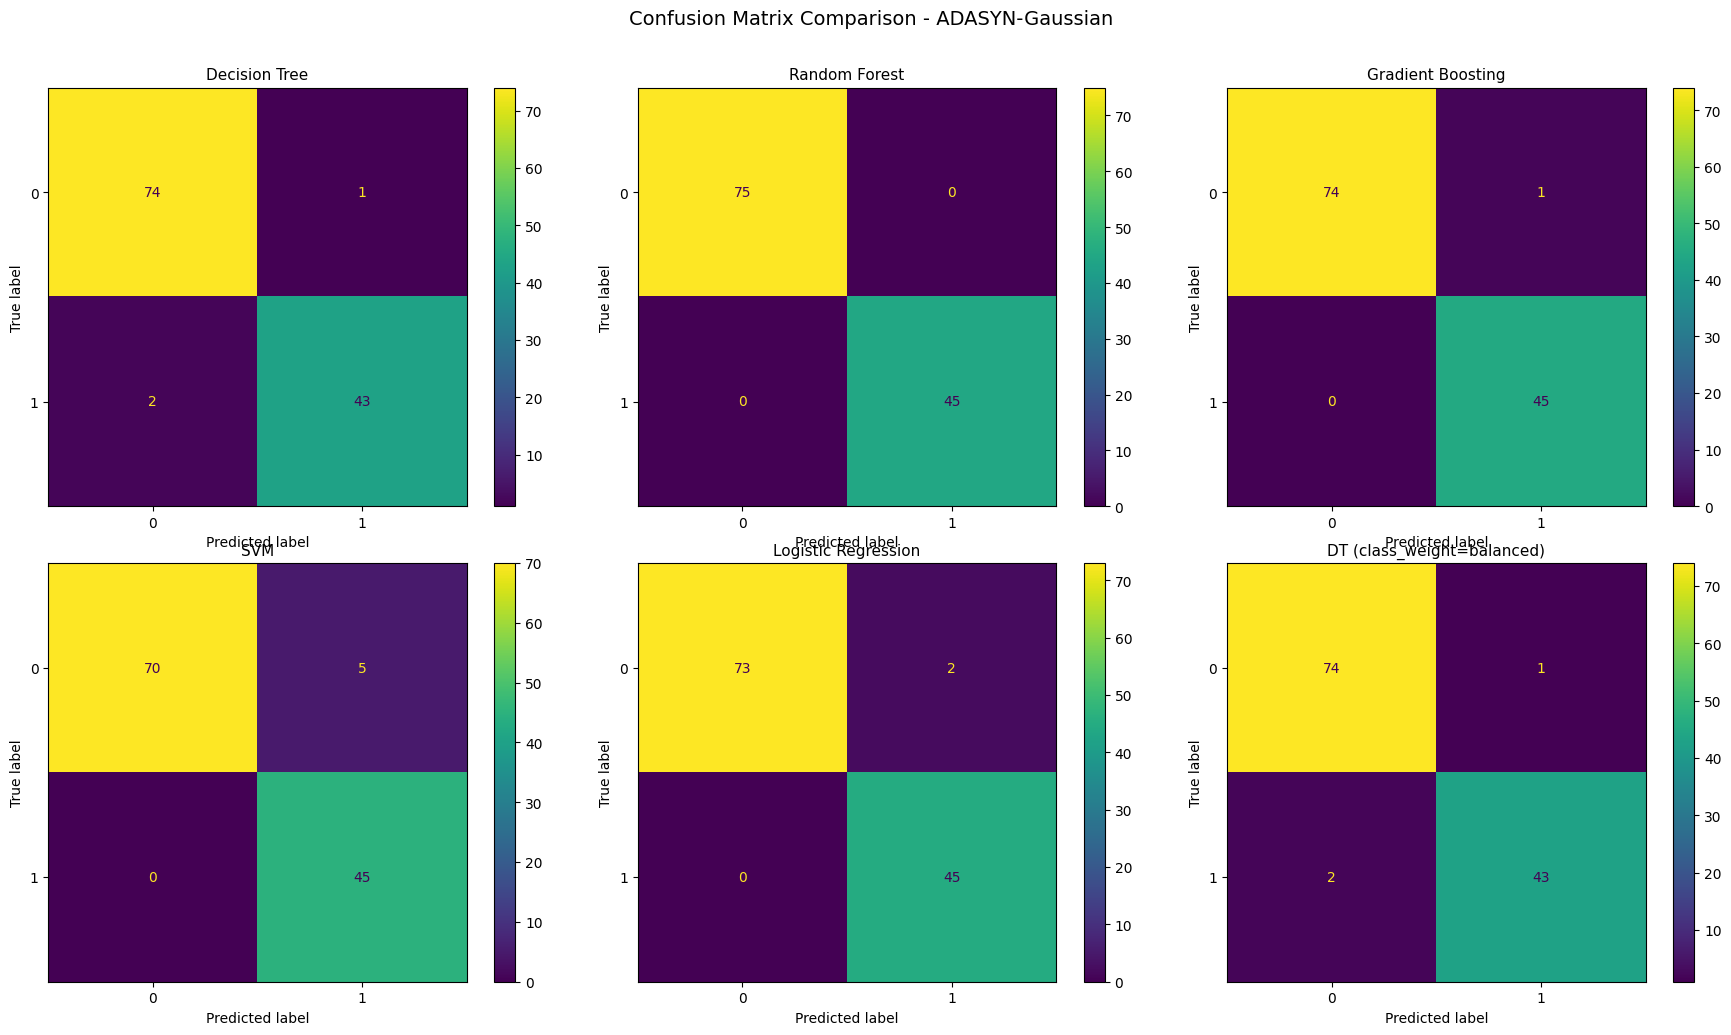

In [47]:
# Confusion Matrix Comparison - Semua Classifiers (ADASYN-Gaussian)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (name, clf) in enumerate(classifiers.items()):
    y_pred_clf = clf.predict(X_test_ag_scaled)
    ax = axes.flatten()[idx]
    ConfusionMatrixDisplay.from_predictions(y_test_ag, y_pred_clf, ax=ax)
    ax.set_title(f'{name}', fontsize=11)

plt.suptitle('Confusion Matrix Comparison - ADASYN-Gaussian', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## ADASYN

In [48]:
from imblearn.over_sampling import ADASYN 
from collections import Counter

In [49]:
# Check class distribution before augmentation
print(f'Original class distribution: {Counter(y_train)}')

Original class distribution: Counter({np.int64(0): 175, np.int64(1): 105})


In [50]:
# Tuning n_neighbors untuk ADASYN
from collections import Counter

best_adasyn_f1 = 0
best_adasyn_n = 2
best_X_res = None
best_y_res = None

for n_neighbors in [2, 3, 5, 7]:
    try:
        adasyn_temp = ADASYN(sampling_strategy='minority', n_neighbors=n_neighbors, random_state=42)
        X_res_temp, y_res_temp = adasyn_temp.fit_resample(X_train, y_train)
        
        # Quick evaluation with Decision Tree
        dt_temp = DecisionTreeClassifier(random_state=42)
        dt_temp.fit(X_res_temp, y_res_temp)
        y_pred_temp = dt_temp.predict(X_test)
        f1_temp = f1_score(y_test, y_pred_temp, zero_division=0)
        
        print(f"n_neighbors={n_neighbors}: distribution={Counter(y_res_temp)}, F1={f1_temp:.4f}")
        
        if f1_temp > best_adasyn_f1:
            best_adasyn_f1 = f1_temp
            best_adasyn_n = n_neighbors
            best_X_res = X_res_temp
            best_y_res = y_res_temp
    except Exception as e:
        print(f"n_neighbors={n_neighbors}: Error - {e}")

print(f"\nBest n_neighbors: {best_adasyn_n} with F1: {best_adasyn_f1:.4f}")

# Gunakan hasil terbaik
X_resampled = best_X_res
y_resampled = best_y_res

n_neighbors=2: distribution=Counter({np.int64(0): 175, np.int64(1): 165}), F1=0.9778
n_neighbors=3: distribution=Counter({np.int64(1): 193, np.int64(0): 175}), F1=0.9663
n_neighbors=5: distribution=Counter({np.int64(0): 175, np.int64(1): 168}), F1=0.9556
n_neighbors=7: distribution=Counter({np.int64(0): 175, np.int64(1): 157}), F1=0.9890

Best n_neighbors: 7 with F1: 0.9890


In [51]:
# Check class distribution after augmentation
print(f'Resampled class distribution (n_neighbors={best_adasyn_n}): {Counter(y_resampled)}')

Resampled class distribution (n_neighbors=7): Counter({np.int64(0): 175, np.int64(1): 157})


In [52]:
n_samples = X_resampled.shape[0]
transformer = QuantileTransformer(n_quantiles=min(n_samples, 1000), output_distribution='normal')

X_resampled_scaled = transformer.fit_transform(X_resampled)
X_test_scaled2 = transformer.transform(X_test)

In [53]:
param_grid = {
    'max_depth': [10, 20, 30],        
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 2, 4]   
}

# Initialize GridSearchCV
grid_search = GridSearchCV(dt, param_grid, cv=10, scoring='accuracy', verbose=2, n_jobs=-1)

# Fit the model
grid_search.fit(X_resampled_scaled, y_resampled)

Fitting 10 folds for each of 27 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

In [54]:
# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Best Parameters: {best_params}")
print(f"Best Score: {best_score}")

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Score: 0.9818181818181818


In [55]:
y_pred = grid_search.best_estimator_.predict(X_test_scaled2)

In [56]:
print("=== Standard ADASYN + Decision Tree (Chronic Kidney Disease) ===")
print("Akurasi      :", accuracy_score(y_test, y_pred))
print("Precision    :", precision_score(y_test, y_pred))
print("Recall       :", recall_score(y_test, y_pred))
print("F1 Score     :", f1_score(y_test, y_pred))

=== Standard ADASYN + Decision Tree (Chronic Kidney Disease) ===
Akurasi      : 0.9916666666666667
Precision    : 0.9782608695652174
Recall       : 1.0
F1 Score     : 0.989010989010989


              precision    recall  f1-score   support

           0       1.00      0.99      0.99        75
           1       0.98      1.00      0.99        45

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



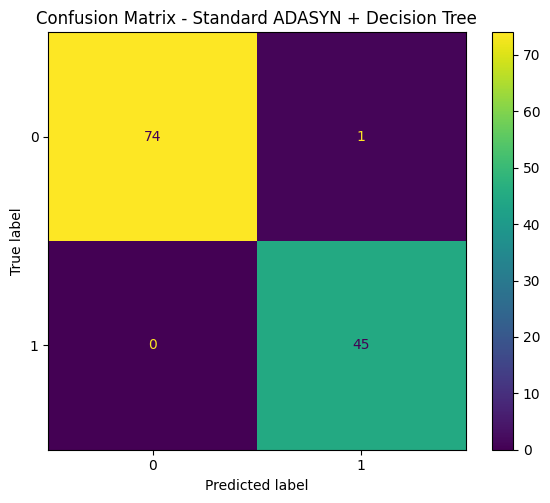

In [57]:
# Classification report
report = classification_report(y_test, y_pred, zero_division=1)
print(report)

# Confusion Matrix
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
ax.set_title('Confusion Matrix - Standard ADASYN + Decision Tree')
plt.tight_layout()
plt.show()

In [58]:
# Perbandingan Multiple Classifiers dengan Standard ADASYN
classifiers_adasyn = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'DT (class_weight=balanced)': DecisionTreeClassifier(class_weight='balanced', random_state=42)
}

results_adasyn = []
roc_data_adasyn = {}

for name, clf in classifiers_adasyn.items():
    print(f"Training {name}...")
    clf.fit(X_resampled_scaled, y_resampled)
    y_pred_clf = clf.predict(X_test_scaled2)
    y_prob_clf = clf.predict_proba(X_test_scaled2)[:, 1]
    
    acc = accuracy_score(y_test, y_pred_clf)
    prec = precision_score(y_test, y_pred_clf, zero_division=0)
    rec = recall_score(y_test, y_pred_clf, zero_division=0)
    f1 = f1_score(y_test, y_pred_clf, zero_division=0)
    auc = roc_auc_score(y_test, y_prob_clf)
    
    results_adasyn.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    })
    
    fpr_clf, tpr_clf, _ = roc_curve(y_test, y_prob_clf)
    roc_data_adasyn[name] = (fpr_clf, tpr_clf, auc)

results_adasyn_df = pd.DataFrame(results_adasyn).sort_values('F1 Score', ascending=False)
print("\n=== Hasil Perbandingan Classifiers dengan Standard ADASYN ===")
display(results_adasyn_df)

Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training SVM...
Training Logistic Regression...
Training DT (class_weight=balanced)...

=== Hasil Perbandingan Classifiers dengan Standard ADASYN ===


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,1.0000,1.0000,1.0,1.0000,1.0000
0,Decision Tree,0.9917,0.9783,1.0,0.9890,0.9933
2,Gradient Boosting,0.9917,0.9783,1.0,0.9890,1.0000
5,DT (class_weight=balanced),0.9917,0.9783,1.0,0.9890,0.9933
4,Logistic Regression,0.9583,0.9000,1.0,0.9474,0.9988
3,SVM,0.9333,0.8491,1.0,0.9184,0.9991


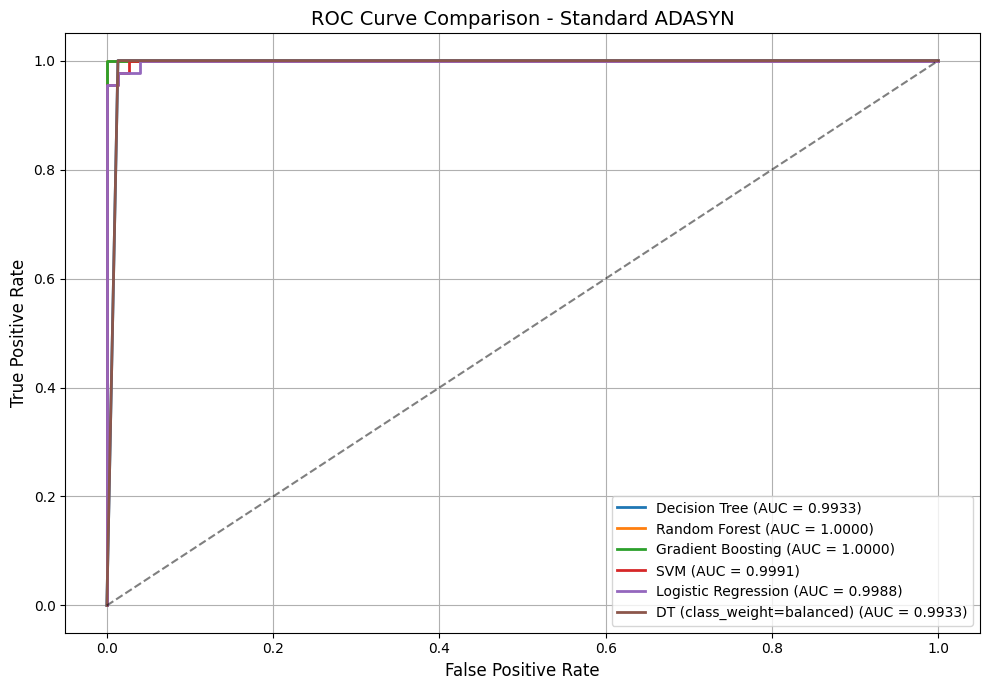

In [59]:
# ROC Curve Comparison - Semua Classifiers (Standard ADASYN)
plt.figure(figsize=(10, 7))
for name, (fpr_clf, tpr_clf, auc_clf) in roc_data_adasyn.items():
    plt.plot(fpr_clf, tpr_clf, label=f'{name} (AUC = {auc_clf:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison - Standard ADASYN', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

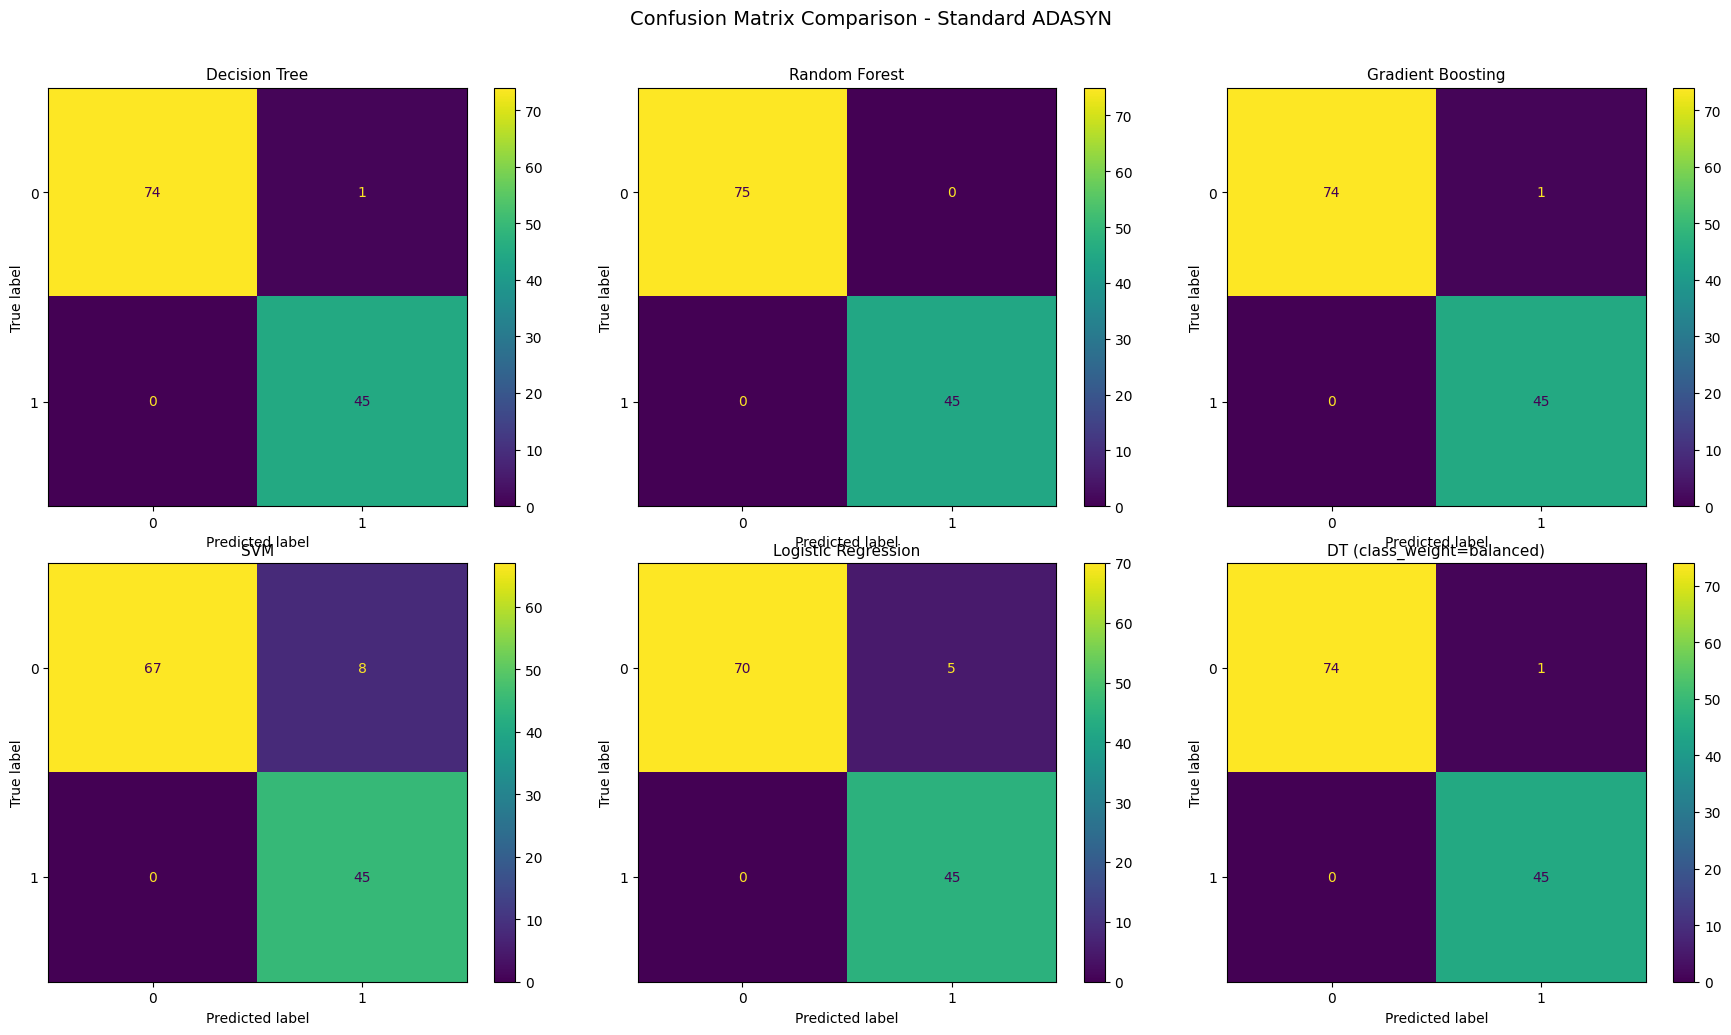

In [60]:
# Confusion Matrix Comparison - Semua Classifiers (Standard ADASYN)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (name, clf) in enumerate(classifiers_adasyn.items()):
    y_pred_clf = clf.predict(X_test_scaled2)
    ax = axes.flatten()[idx]
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_clf, ax=ax)
    ax.set_title(f'{name}', fontsize=11)

plt.suptitle('Confusion Matrix Comparison - Standard ADASYN', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Perbandingan Akhir: ADASYN-Gaussian vs Standard ADASYN

In [61]:
# Tabel Perbandingan ADASYN-Gaussian vs Standard ADASYN
results_ag_df['Method'] = 'ADASYN-Gaussian'
results_adasyn_df['Method'] = 'Standard ADASYN'

comparison_df = pd.concat([results_ag_df, results_adasyn_df], ignore_index=True)
comparison_df = comparison_df[['Method', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']]
comparison_df = comparison_df.sort_values(['Model', 'Method'])

print("=== Perbandingan Akhir: ADASYN-Gaussian vs Standard ADASYN ===")
display(comparison_df)

# Highlight best F1 per method
print("\n--- Best Model per Method ---")
for method in ['ADASYN-Gaussian', 'Standard ADASYN']:
    best = comparison_df[comparison_df['Method'] == method].sort_values('F1 Score', ascending=False).iloc[0]
    print(f"{method}: {best['Model']} (F1={best['F1 Score']}, AUC={best['ROC-AUC']})")

=== Perbandingan Akhir: ADASYN-Gaussian vs Standard ADASYN ===


,Method,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,ADASYN-Gaussian,DT (class_weight=balanced),0.9750,0.9773,0.9556,0.9663,0.9711
9,Standard ADASYN,DT (class_weight=balanced),0.9917,0.9783,1.0000,0.9890,0.9933
3,ADASYN-Gaussian,Decision Tree,0.9750,0.9773,0.9556,0.9663,0.9711
7,Standard ADASYN,Decision Tree,0.9917,0.9783,1.0000,0.9890,0.9933
1,ADASYN-Gaussian,Gradient Boosting,0.9917,0.9783,1.0000,0.9890,1.0000
8,Standard ADASYN,Gradient Boosting,0.9917,0.9783,1.0000,0.9890,1.0000
2,ADASYN-Gaussian,Logistic Regression,0.9833,0.9574,1.0000,0.9783,0.9997
10,Standard ADASYN,Logistic Regression,0.9583,0.9000,1.0000,0.9474,0.9988
0,ADASYN-Gaussian,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
6,Standard ADASYN,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000



--- Best Model per Method ---
ADASYN-Gaussian: Random Forest (F1=1.0, AUC=1.0)
Standard ADASYN: Random Forest (F1=1.0, AUC=1.0)


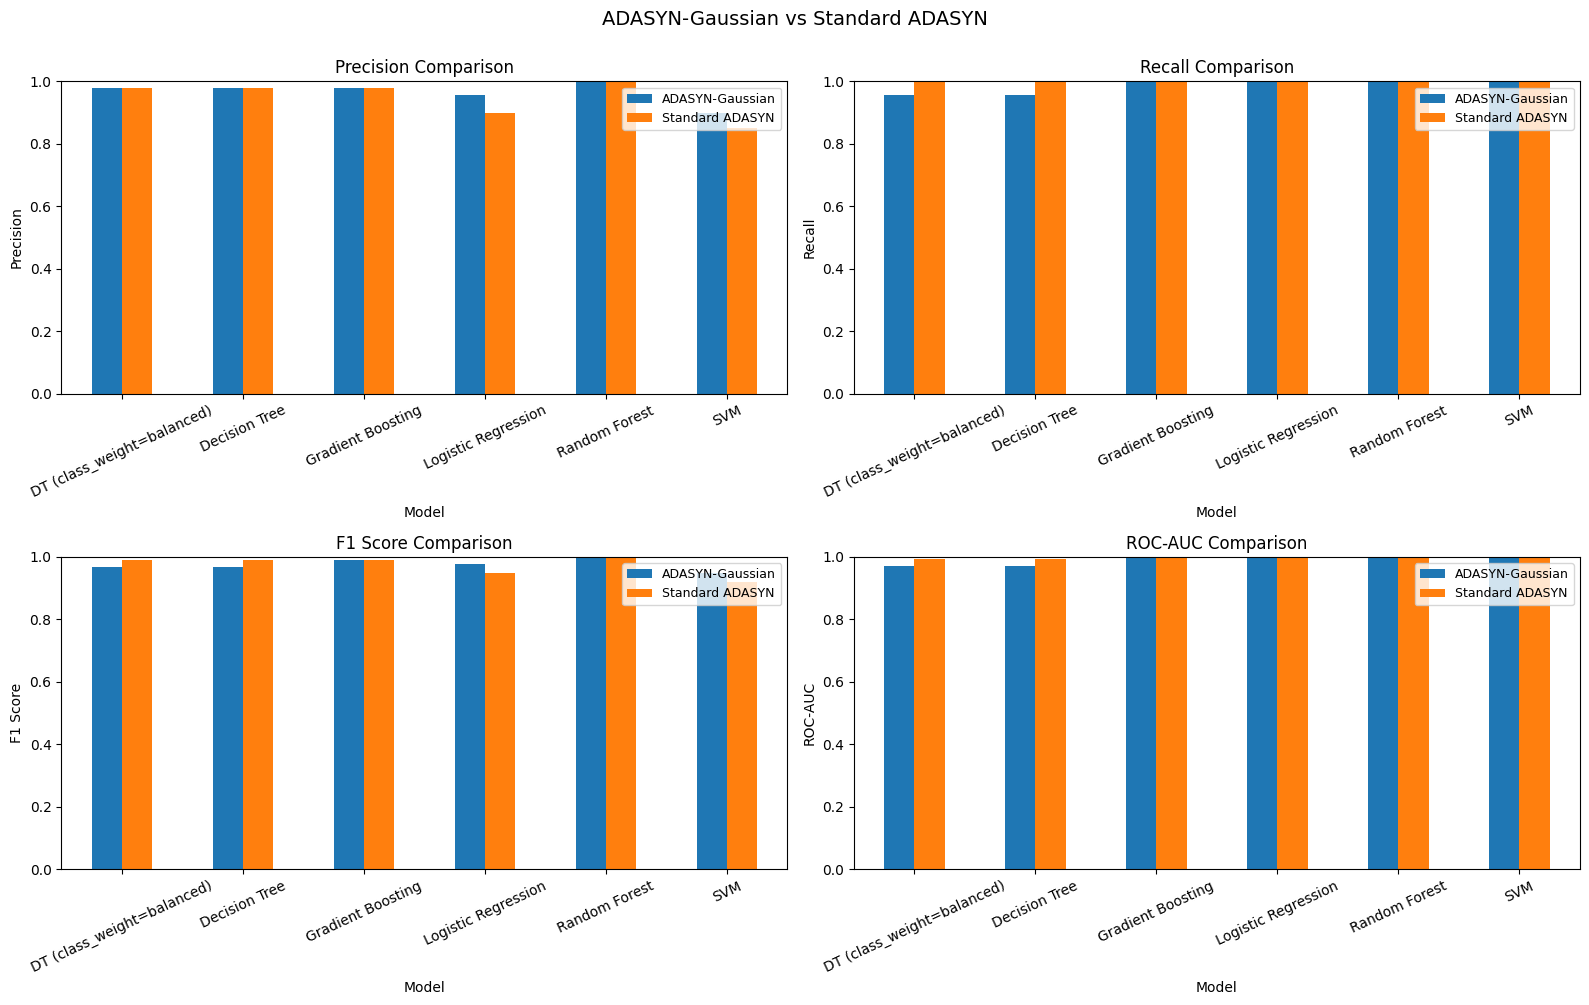

In [62]:
# Visualisasi Bar Chart Perbandingan dengan Precision
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics_to_plot = ['Precision', 'Recall', 'F1 Score', 'ROC-AUC']
for i, metric in enumerate(metrics_to_plot):
    ax = axes.flatten()[i]
    pivot = comparison_df.pivot(index='Model', columns='Method', values=metric)
    pivot.plot(kind='bar', ax=ax, rot=25)
    ax.set_title(f'{metric} Comparison', fontsize=12)
    ax.set_ylabel(metric)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1)

plt.suptitle('ADASYN-Gaussian vs Standard ADASYN', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()